In [1]:
%matplotlib widget

In [2]:
# Importando as ferramentas necessárias
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Para tornar os gráficos mais bonitos
plt.style.use('seaborn-v0_8')

In [3]:
# DEFININDO AS EQUAÇÕES DO REPRESSILADOR
def repressilator(t, y, alpha, n, beta):
    """
    Sistema de equações diferenciais do Repressilador
    t: tempo
    y: variáveis [m1, m2, m3, p1, p2, p3]
    alpha, n, beta: parâmetros do modelo
    """
    m1, m2, m3, p1, p2, p3 = y
    
    # Equações para o mRNA (m)
    dm1_dt = -m1 + alpha / (1 + p3**n)
    dm2_dt = -m2 + alpha / (1 + p1**n)
    dm3_dt = -m3 + alpha / (1 + p2**n)
    
    # Equações para as proteínas (p)
    dp1_dt = -beta * (p1 - m1)
    dp2_dt = -beta * (p2 - m2)
    dp3_dt = -beta * (p3 - m3)
    
    return [dm1_dt, dm2_dt, dm3_dt, dp1_dt, dp2_dt, dp3_dt]

In [4]:
# PARÂMETROS DO MODELO (você pode alterar esses valores!)
alpha = 100  # Força de produção
n = 2        # Coeficiente de Hill (cooperatividade)
beta = 0.2   # Razão entre degradação de proteína e mRNA

# Condições iniciais: [m1, m2, m3, p1, p2, p3]
y0 = [0.1, 0.2, 0.3, 0.1, 0.2, 0.3]

# Tempo de simulação
t_span = (0, 200)
t_eval = np.linspace(0, 200, 1000)

In [5]:
# RESOLVENDO AS EQUAÇÕES DIFERENCIAIS
print("Resolvendo as equações do repressilador...")
solution = solve_ivp(repressilator, t_span, y0, args=(alpha, n, beta), 
                     t_eval=t_eval, method='RK45')

print("Simulação concluída!")

Resolvendo as equações do repressilador...
Simulação concluída!


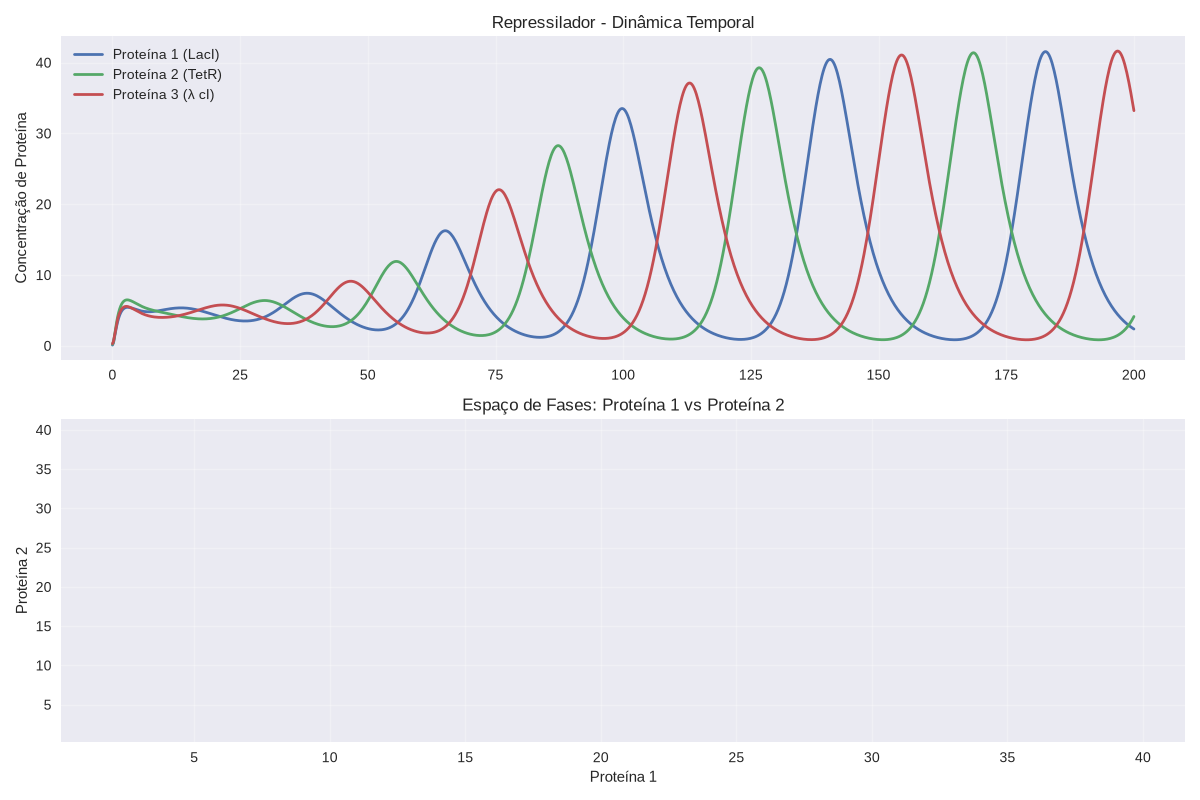

In [6]:
# CRIANDO O GRÁFICO ANIMADO
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Configuração da figura
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Extraindo os resultados
t = solution.t
m1, m2, m3, p1, p2, p3 = solution.y

# Plot 1: Proteínas ao longo do tempo
lines_p = []
for i, (data, label) in enumerate([(p1, 'Proteína 1 (LacI)'), 
                                  (p2, 'Proteína 2 (TetR)'), 
                                  (p3, 'Proteína 3 (λ cI)')]):
    line, = ax1.plot(t, data, label=label, linewidth=2)
    lines_p.append(line)

ax1.set_ylabel('Concentração de Proteína')
ax1.set_title('Repressilador - Dinâmica Temporal')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Espaço de fases (Proteína 1 vs Proteína 2)
phase_line, = ax2.plot([], [], 'r-', linewidth=1, alpha=0.7)
ax2.set_xlabel('Proteína 1')
ax2.set_ylabel('Proteína 2')
ax2.set_title('Espaço de Fases: Proteína 1 vs Proteína 2')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(min(p1), max(p1))
ax2.set_ylim(min(p2), max(p2))

def animate(frame):
    # Atualizar o espaço de fases até o frame atual
    phase_line.set_data(p1[:frame], p2[:frame])
    return phase_line,

# Criar a animação
anim = FuncAnimation(fig, animate, frames=len(t), interval=20, blit=True)

plt.tight_layout()
plt.show()

# Para salvar a animação (opcional)
# anim.save('repressilador.gif', writer='pillow', fps=30)

In [7]:
# ANÁLISE DAS OSCILAÇÕES
print("\n=== ANÁLISE DO COMPORTAMENTO OSCILATÓRIO ===")

# Encontrando picos nas oscilações da Proteína 1
from scipy.signal import find_peaks

peaks, _ = find_peaks(p1, height=np.mean(p1))
periods = np.diff(t[peaks])

if len(periods) > 0:
    print(f"Número de oscilações completas: {len(periods)}")
    print(f"Período médio: {np.mean(periods):.2f} unidades de tempo")
    print(f"Amplitude média: {np.mean(p1[peaks]):.2f}")
else:
    print("Sistema não está oscilando! Tente aumentar 'alpha'.")


=== ANÁLISE DO COMPORTAMENTO OSCILATÓRIO ===
Número de oscilações completas: 3
Período médio: 39.11 unidades de tempo
Amplitude média: 32.94


In [ ]:
# CRIANDO UMA ANIMAÇÃO QUE CRESCE DIANTE DOS OLHOS!
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import time

# Configuração da figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Dados da simulação
t = solution.t
m1, m2, m3, p1, p2, p3 = solution.y

# Setup dos gráficos vazios
# Gráfico 1: Proteínas ao longo do tempo
line1, = ax1.plot([], [], 'b-', label='Proteína 1 (LacI)', linewidth=2)
line2, = ax1.plot([], [], 'r-', label='Proteína 2 (TetR)', linewidth=2) 
line3, = ax1.plot([], [], 'g-', label='Proteína 3 (λ cI)', linewidth=2)
ax1.set_xlim(0, max(t))
ax1.set_ylim(0, max(max(p1), max(p2), max(p3)) * 1.1)
ax1.set_xlabel('Tempo')
ax1.set_ylabel('Concentração')
ax1.set_title('REPRESSILADOR - Oscilações em Tempo Real')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Espaço de fases
phase_line, = ax2.plot([], [], 'purple', linewidth=2, alpha=0.7)
current_point, = ax2.plot([], [], 'ro', markersize=8)
ax2.set_xlim(min(p1), max(p1))
ax2.set_ylim(min(p2), max(p2))
ax2.set_xlabel('Proteína 1')
ax2.set_ylabel('Proteína 2')
ax2.set_title('Espaço de Fases - Trajetória')
ax2.grid(True, alpha=0.3)

# Texto informativo
time_text = ax1.text(0.02, 0.98, '', transform=ax1.transAxes, fontsize=12,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()

# Função de animação
def animate(frame):
    # Atualizar gráfico temporal
    line1.set_data(t[:frame], p1[:frame])
    line2.set_data(t[:frame], p2[:frame])
    line3.set_data(t[:frame], p3[:frame])
    
    # Atualizar espaço de fases
    phase_line.set_data(p1[:frame], p2[:frame])
    if frame > 0:
        current_point.set_data([p1[frame-1]], [p2[frame-1]])
    
    # Atualizar texto
    time_text.set_text(f'Tempo: {t[frame-1] if frame > 0 else 0:.1f}\nFrame: {frame}/{len(t)}')
    
    return line1, line2, line3, phase_line, current_point, time_text

# Criar a animação
print("Criando animação...")
anim = FuncAnimation(fig, animate, frames=len(t), interval=1, blit=True, repeat=True)

# Mostrar a animação
plt.close()  # Previne que mostre o plot estático
HTML(anim.to_jshtml())

Criando animação...


Iniciando simulação em tempo real...


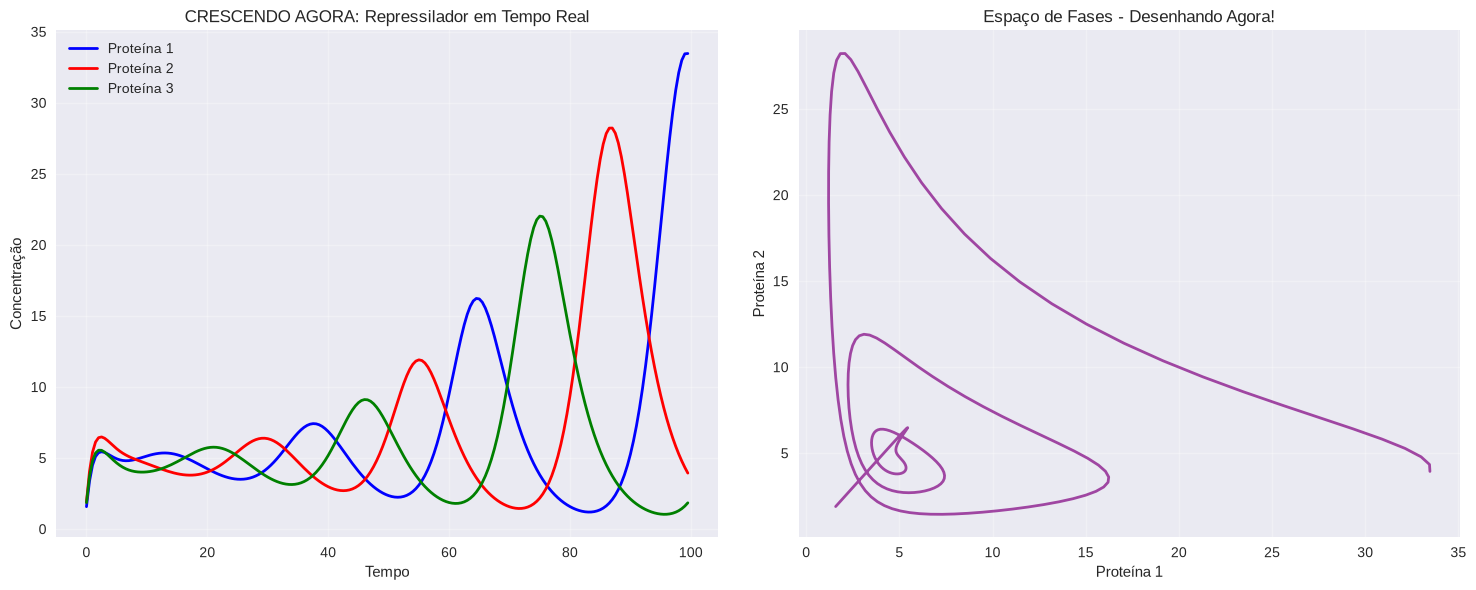

In [ ]:
import time
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp  # Import correto para solve_ivp


# Definição do sistema de equações do Repressilador
def repressilator(t, y, alpha, n, beta):
  # y = [m1, m2, m3, p1, p2, p3]
  m1, m2, m3, p1, p2, p3 = y

  # Equações para os mRNAs e Proteínas (Elowitz & Leibler, 2000)
  dm1_dt = -m1 + alpha / (1 + p3**n)
  dm2_dt = -m2 + alpha / (1 + p1**n)
  dm3_dt = -m3 + alpha / (1 + p2**n)

  dp1_dt = -beta * (p1 - m1)
  dp2_dt = -beta * (p2 - m2)
  dp3_dt = -beta * (p3 - m3)

  return [dm1_dt, dm2_dt, dm3_dt, dp1_dt, dp2_dt, dp3_dt]


# Parâmetros da simulação
alpha = 100
n = 2
beta = 0.2

# Configuração do gráfico
plt.ion()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

t_data = []
p1_data, p2_data, p3_data = [], [], []

# Condições iniciais: [m1, m2, m3, p1, p2, p3]
y0 = [0.1, 0.2, 0.3, 0.1, 0.2, 0.3]

# Linhas dos gráficos
(line1,) = ax1.plot([], [], 'b-', label='Proteína 1', linewidth=2)
(line2,) = ax1.plot([], [], 'r-', label='Proteína 2', linewidth=2)
(line3,) = ax1.plot([], [], 'g-', label='Proteína 3', linewidth=2)
(phase_line,) = ax2.plot([], [], '-', color='purple', linewidth=2, alpha=0.7)

ax1.set_xlabel('Tempo')
ax1.set_ylabel('Concentração')
ax1.set_title('CRESCENDO AGORA: Repressilador em Tempo Real')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Proteína 1')
ax2.set_ylabel('Proteína 2')
ax2.set_title('Espaço de Fases - Desenhando Agora!')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

print('Iniciando simulação em tempo real...')

try:
  for i in range(200):
    t_current = i * 0.5
    sol = solve_ivp(
        repressilator,
        [t_current, t_current + 0.5],
        y0,
        args=(alpha, n, beta),
        method='RK45',
    )

    t_data.append(t_current)
    p1_data.append(sol.y[3][-1])
    p2_data.append(sol.y[4][-1])
    p3_data.append(sol.y[5][-1])

    y0 = [sol.y[j][-1] for j in range(6)]

    # Atualiza gráficos
    line1.set_data(t_data, p1_data)
    line2.set_data(t_data, p2_data)
    line3.set_data(t_data, p3_data)
    phase_line.set_data(p1_data, p2_data)

    # Reajuste dinâmico de limites
    ax1.relim()
    ax1.autoscale_view()
    ax2.relim()
    ax2.autoscale_view()

    fig.canvas.draw()
    fig.canvas.flush_events()
    time.sleep(0.01)

except KeyboardInterrupt:
  print('\nSimulação interrompida pelo usuário')

plt.ioff()
plt.show()

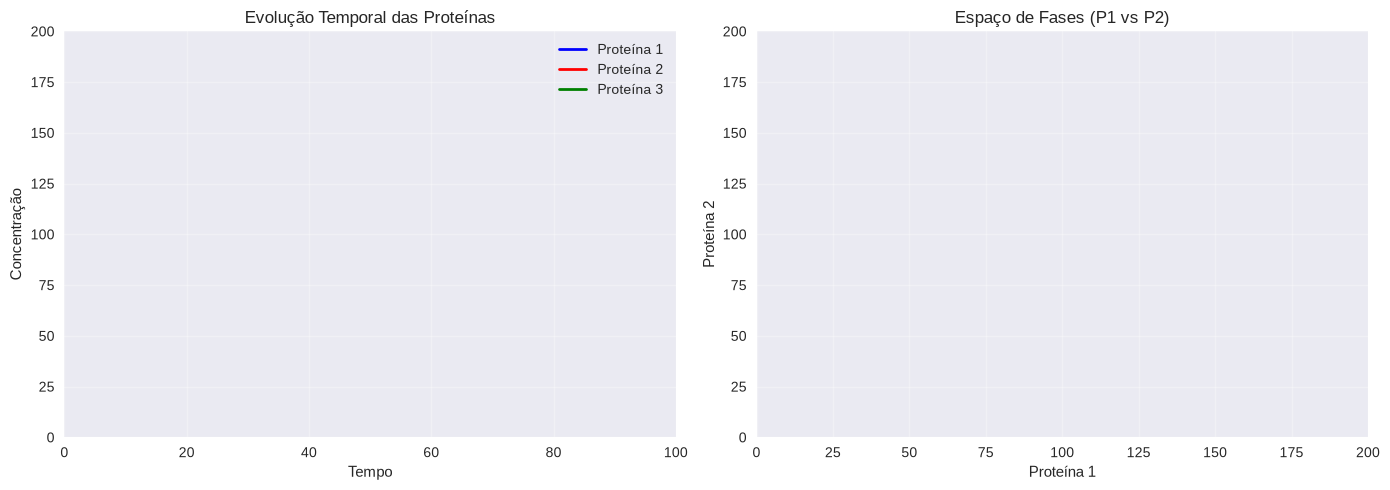

In [ ]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp


# 1. Definição do sistema do Repressilador
def repressilator(t, y, alpha, n, beta):
  m1, m2, m3, p1, p2, p3 = y

  dm1_dt = -m1 + alpha / (1 + p3**n)
  dm2_dt = -m2 + alpha / (1 + p1**n)
  dm3_dt = -m3 + alpha / (1 + p2**n)

  dp1_dt = -beta * (p1 - m1)
  dp2_dt = -beta * (p2 - m2)
  dp3_dt = -beta * (p3 - m3)

  return [dm1_dt, dm2_dt, dm3_dt, dp1_dt, dp2_dt, dp3_dt]


# 2. Parâmetros do sistema
alpha = 100
n = 2
beta = 0.2
dt = 0.5  # Passo de tempo por frame

# Arrays de dados zerados
t_data = []
p1_data, p2_data, p3_data = [], [], []

# Condições iniciais [m1, m2, m3, p1, p2, p3]
y_current = [0.1, 0.2, 0.3, 0.1, 0.2, 0.3]

# 3. Configuração dos gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

(line1,) = ax1.plot([], [], 'b-', label='Proteína 1', linewidth=2)
(line2,) = ax1.plot([], [], 'r-', label='Proteína 2', linewidth=2)
(line3,) = ax1.plot([], [], 'g-', label='Proteína 3', linewidth=2)
(phase_line,) = ax2.plot([], [], '-', color='purple', linewidth=2, alpha=0.7)

ax1.set_xlim(0, 100)
ax1.set_ylim(0, 200)
ax1.set_xlabel('Tempo')
ax1.set_ylabel('Concentração')
ax1.set_title('Evolução Temporal das Proteínas')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2.set_xlim(0, 200)
ax2.set_ylim(0, 200)
ax2.set_xlabel('Proteína 1')
ax2.set_ylabel('Proteína 2')
ax2.set_title('Espaço de Fases (P1 vs P2)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()


# 4. Função de atualização chamada a cada frame
def update(frame):
  global y_current

  t_current = frame * dt

  # Resolve o próximo intervalo de tempo
  sol = solve_ivp(
      repressilator,
      [t_current, t_current + dt],
      y_current,
      args=(alpha, n, beta),
      method='RK45',
  )

  # Atualiza as variáveis com o último ponto calculado
  t_data.append(t_current)
  p1_data.append(sol.y[3][-1])
  p2_data.append(sol.y[4][-1])
  p3_data.append(sol.y[5][-1])

  y_current = [sol.y[i][-1] for i in range(6)]

  # Atualiza os dados das linhas (redesenho ultra-rápido)
  line1.set_data(t_data, p1_data)
  line2.set_data(t_data, p2_data)
  line3.set_data(t_data, p3_data)
  phase_line.set_data(p1_data, p2_data)

  # Ajusta eixos dinamicamente
  ax1.set_xlim(0, max(100, t_current))
  max_val = max(max(p1_data), max(p2_data), max(p3_data))
  ax1.set_ylim(0, max_val * 1.1)

  ax2.set_xlim(min(p1_data) * 0.9, max(p1_data) * 1.1)
  ax2.set_ylim(min(p2_data) * 0.9, max(p2_data) * 1.1)

  # Retorna os objetos atualizados
  return line1, line2, line3, phase_line


# 5. Inicialização da animação
ani = animation.FuncAnimation(
    fig,
    update,
    frames=400,  # Quantidade de passos
    interval=20,  # Tempo entre frames em ms (50 FPS)
    repeat=False,
    blit=False,  # Recomenda-se False ao redimensionar eixos dinamicamente
)

plt.show()